In [1]:
import os
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import * 
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

ModuleNotFoundError: No module named 'plotUtils'

In [ ]:
# Vectorized euler intergration implementation

def euler_intergrate(u, init_point, modNodes,  **opts):
    # common parameters
    beta = opts.get('beta')
    gamma = opts.get('gamma')
    theta = opts.get('theta')

    nTrials, _ = init_point.shape
    nNodes = opts.get("N")

    for q in range(nTrials):
        u[q, :, 0] = init_point[0, :] if init_point.shape[0] == 1 else  init_point[q, :]       # initializing membrane potentials
        Abar = opts.get('Abar')[0] if opts.get('Abar').shape[0] == 1 else opts.get('Abar')[q] 
        
        for t in range(opts.get('T') - 1):
            Fvect = np.zeros((2 * nNodes, 1))
            Imod = np.zeros((2 * nNodes, 1))

            for n in range(nNodes):
                Fvect[2 * n] = F(u[q, 2 * n, t], beta, theta, gamma, opts.get('sigma')[2 * n])
                Fvect[2 * n + 1] = F(u[q, 2 * n + 1, t], beta, theta, gamma, opts.get('sigma')[2 * n + 1])

                Imod[2 * n] = opts.get('i_mod') if n in modNodes else 0

            uVect = -u[q, :, t].reshape(-1, 1) + opts.get('W') @ Fvect + opts.get('Kglob') * Abar @ u[q, :, t].reshape(-1, 1) + opts.get('i_bias') + Imod
            uVect = opts.get('dt') * opts.get('Tau') @ uVect
            u[q, :, t + 1] = u[q, :, t] + uVect.flatten()           # updating membrane potentials
            
    return u

In [ ]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
nTrials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

params["N"] = nNodes = 10

In [ ]:
# Creating P matrix

def modelP(N, nTrials, WD="High"):
    P = np.zeros((nTrials, N, N))

    for q in range(nTrials):
        P[q] = np.random.standard_exponential((nNodes, nNodes))
        P[q] -= np.diag(np.diag(P[q]))
        P[q] = (P[q] + P[q].T) / 2

        norm_factor = np.max(P[q].sum(axis=1))
        P[q] /= norm_factor

        ROI = np.arange(0, nNodes)

        if WD == "High":
            WeightDeg = np.argmax(P[q].sum(axis=1))
        else:
            WeightDeg = np.argmin(P[q].sum(axis=1))

        ROI[0] = WeightDeg
        ROI[WeightDeg] = 0

        ROIsort = np.argsort(ROI)
        P[q] = P[q][:, ROIsort][ROIsort, :]
 
    return P, np.arange(0, nNodes)

In [ ]:
P, ROI = modelP(nNodes, nTrials, "Low")

Text(0.5, 1.0, 'Graph Network (N = 10)')

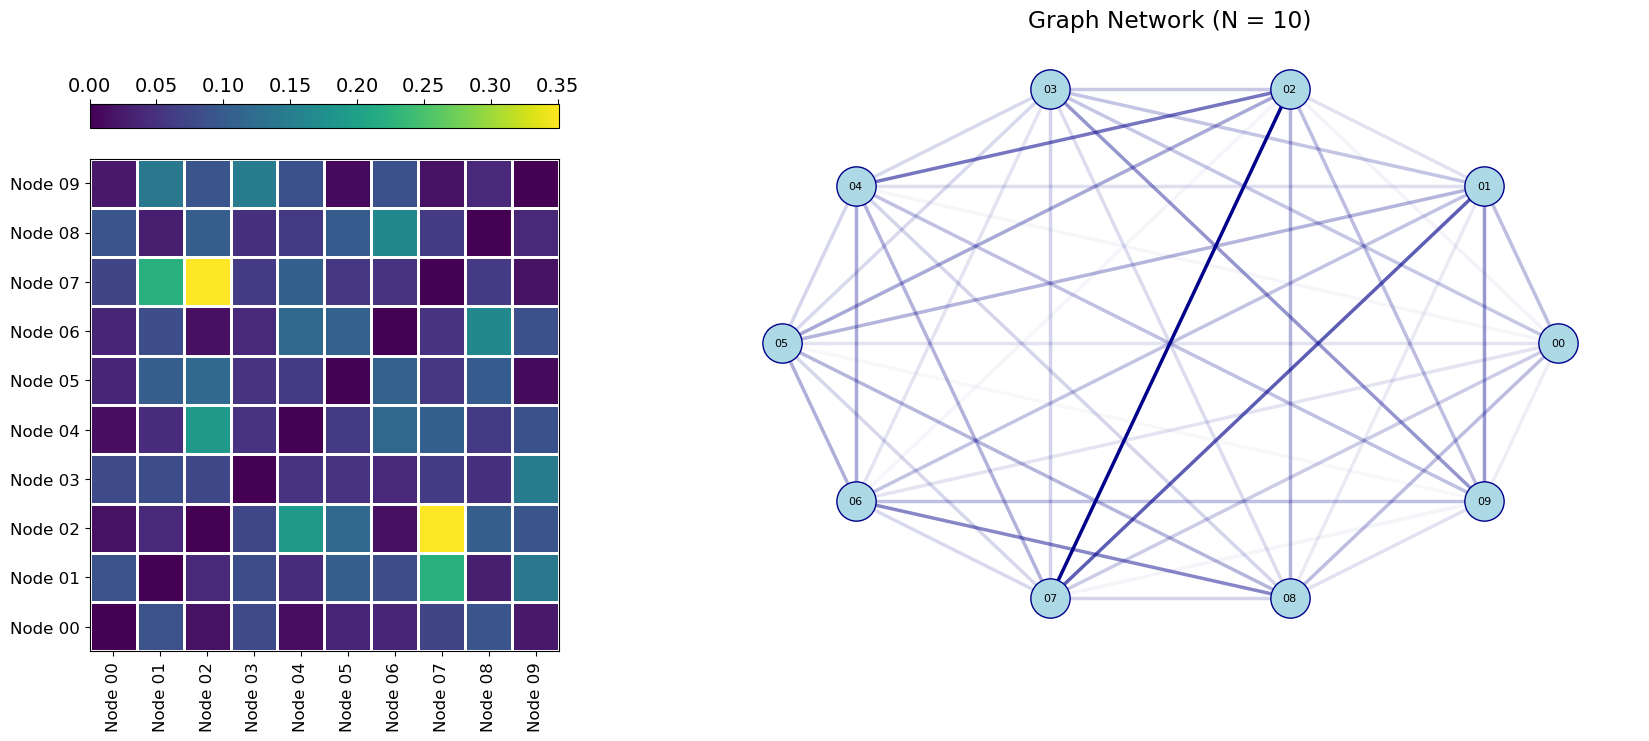

In [ ]:
ROI_no = ROI
A = P[0]

fig, axs = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios':[1, 2]})
pcol = axs[0].pcolormesh(A, edgecolor='w')
axs[0].set_xticks(np.arange(0, nNodes) + 0.5, [f"Node {ROI_no[n]:02d}" for n in range(nNodes)], rotation=90, fontsize=12)
axs[0].set_yticks(np.arange(0, nNodes) + 0.5, [f"Node {ROI_no[n]:02d}" for n in range(nNodes)], fontsize=12)
fig.colorbar(pcol, ax = axs[0], location='top')


G = nx.from_numpy_array(A, parallel_edges=False)
pos = nx.circular_layout(G) 
nx.draw_networkx_nodes(G, pos, ax=axs[1], node_color='lightblue', edgecolors='darkblue', node_size=800)

# Adding labels to the nodes
labels = {}
for n in range(nNodes):
    labels[n] = f"{ROI_no[n]:02d}"

nx.draw_networkx_labels(G, pos, labels, ax=axs[1], font_size=8)

all_weights = []
#4 a. Iterate through the graph nodes to gather all the weights
for (node1, node2, data) in G.edges(data = True):
    all_weights.append(data['weight']) 

#4 b. Get unique weights
unique_weights = list(set(all_weights))
maxWeight = np.max(unique_weights)

#4 c. Plot the edges - one by one!
for weight in unique_weights:
    #4 d. Form a filtered list with just the weight you want to draw
    weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
    nx.draw_networkx_edges(G, pos, ax=axs[1], edge_color='darkblue', alpha = weight / maxWeight, edgelist = weighted_edges, width = 2.5)

#Plot the graph
axs[1].axis('off')
axs[1].set_title(f"Graph Network (N = {nNodes})")

In [ ]:
Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

Abar = np.zeros((nTrials, 2 * nNodes, 2 * nNodes))
for q in range(nTrials):
    Abar[q] = (Dnet.T @ P[q]) @ Dnet

params["Abar"] = Abar 

tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

In [ ]:
# Initialization
random.seed(0)
xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))

In [ ]:
Kmin = -1; Kmax = 1; Ksteps = 10

# Setting variables
window_size = 1000
overlap = 1000

params['Kglob'] = Kmax
params['i_mod'] = 0.5 / params['gamma']
modNodes = [0]
sig_perm = np.array([[2.5, 4.4], [7.5, 4.4], [16.5, 4.4], [2.5, 10.5], [7.5, 10.5], [16.5, 10.5], [2.5, 16.5], [7.5, 16.5], [16.5, 16.5]])

In [ ]:
for ns, (sige, sigi) in enumerate(sig_perm):
    print(f"Evaluating {ns + 1} / {len(sig_perm)} --> sigma = [{sige:.3f}, {sigi:.3f}]^T")
    sigma = np.ones(2 * nNodes)
    sigma[0::2] = sige
    sigma[1::2] = sigi 

    params['sigma'] = sigma

    fileName = f"sige_{params['sigma'][0]:.3f}_sigi_{params['sigma'][1]:.3f}_Imod_{params['i_mod']:.3f}mV_KGlob_{params['Kglob']:.2f}.pkl"

    u = np.zeros((nTrials, 2 * nNodes, T))
    u = euler_intergrate(u, xInit, modNodes = modNodes, **params)

    uMeanTrial = np.mean(u, axis=0)

    fig, axs = plt.subplots(2, 1, sharex=True)

    axs[0].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))
    axs[1].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

    for n in range(nNodes):
        axs[0].plot(time_[:-t_start], uMeanTrial[2 * n, t_start : ])
        axs[1].plot(time_[:-t_start], uMeanTrial[2 * n + 1, t_start : ])
    
    axs[0].set_ylabel(r"$\mathbf{u}_e$")
    axs[1].set_ylabel(r"$\mathbf{u}_i$")
    fig.supxlabel('Time (a.u.)')
    plt.show()


Evaluating 1 / 9 --> sigma = [2.500, 4.400]^T
[ 2.5         4.4        -0.07193554  4.33502858  1.16912723  4.53742434
  2.8320659   2.44809639  3.92774225  4.61730499  4.54265494  4.46069148
  1.16407668  3.86729874  2.55426607  5.41057495  3.34533302  6.0525107
  2.17631443  4.43159218]


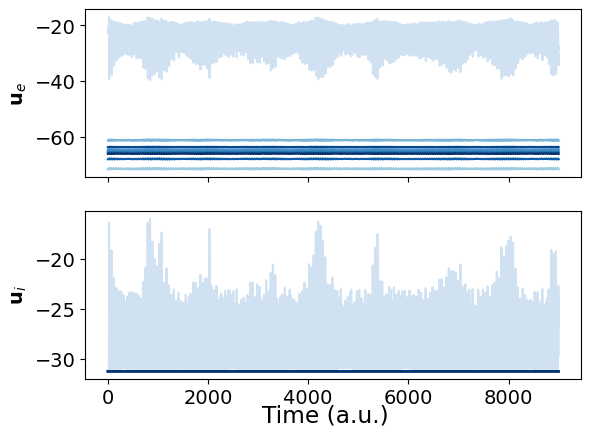

Evaluating 2 / 9 --> sigma = [7.500, 4.400]^T
[7.5        4.4        7.17759582 1.99270903 6.77569149 5.39088006
 6.25842903 4.54724403 9.02907688 5.53062802 7.81889153 2.11471019
 8.53383747 2.29736343 9.11770539 2.36652344 7.40808246 5.65908333
 7.1290476  3.90150973]


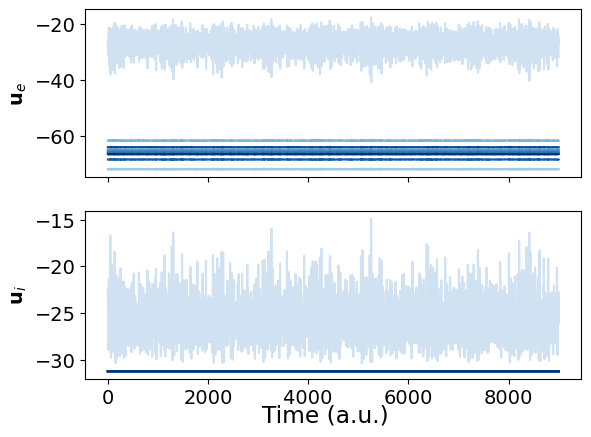

Evaluating 3 / 9 --> sigma = [16.500, 4.400]^T
[16.5         4.4        15.2172005   4.01375048 16.35399593  5.6063103
 15.61800619  4.56648402 16.37319341  5.22380241 16.20525981  2.94850423
 16.03689446  7.07310829 16.55381524  5.55952585 18.61486658  3.96827457
 14.40013197  5.09394793]


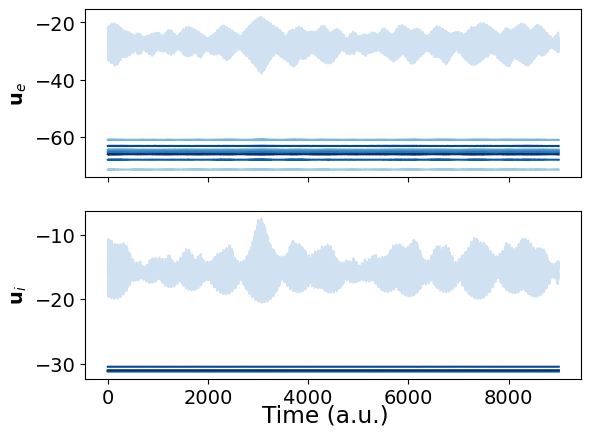

Evaluating 4 / 9 --> sigma = [2.500, 10.500]^T
[ 2.5        10.5         3.23908222  9.74236457  1.93380595 10.48484387
  0.83925459 11.23539889  2.91647402  9.52039053  1.69621318 11.86919116
  1.53978187 11.71061122  1.81460652 11.18121816  2.02000822  9.1626075
  3.74353775 10.69602107]


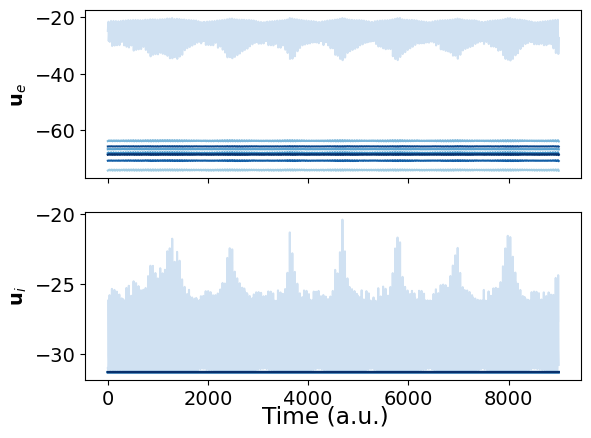

Evaluating 5 / 9 --> sigma = [7.500, 10.500]^T
[ 7.5        10.5         7.30710371 11.07738854  7.24555088 12.30501374
  4.64047653  9.28177178  8.3294138   9.45783965  8.97971565 10.76444922
  7.31690955  8.33506546  6.85428178  9.74474632  6.39763732 10.87418769
  8.18955657 11.3390759 ]


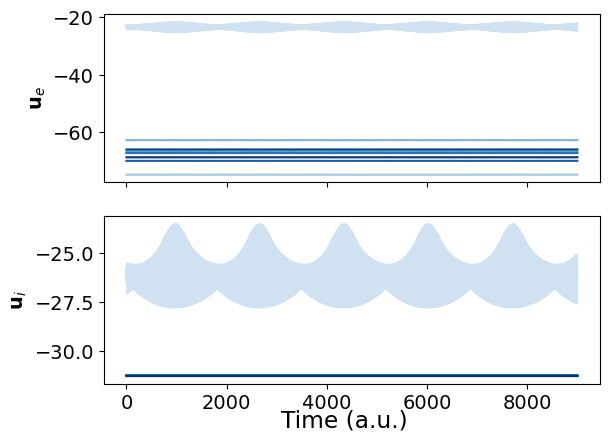

Evaluating 6 / 9 --> sigma = [16.500, 10.500]^T
[16.5        10.5        18.72069873  8.63666043 16.52571681 12.27881763
 16.85628865 10.32576027 14.4567987  10.34479291 15.60185405 11.91232597
 17.45314415  9.95351537 16.42403024  9.33356224 16.88466102 12.31315114
 17.25650254  9.09089574]


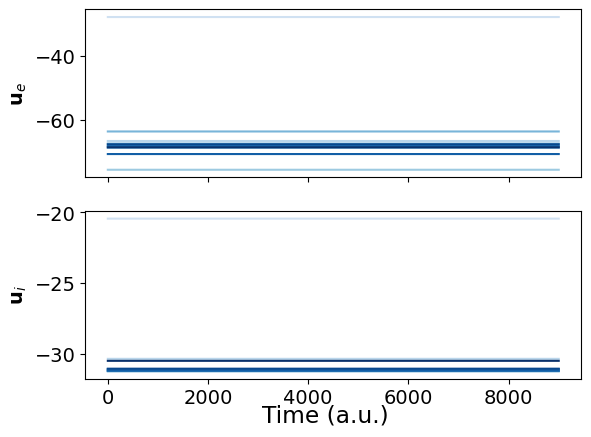

Evaluating 7 / 9 --> sigma = [2.500, 16.500]^T
[2.50000000e+00 1.65000000e+01 1.24841848e+00 1.69948643e+01
 1.66356091e-02 1.50598650e+01 2.57078895e+00 1.66574857e+01
 3.50658461e+00 1.53129995e+01 3.33003482e+00 1.53883897e+01
 2.86405435e+00 1.77729234e+01 3.28828919e+00 1.69403194e+01
 2.05036004e+00 1.84716490e+01 5.07835339e+00 1.52150289e+01]


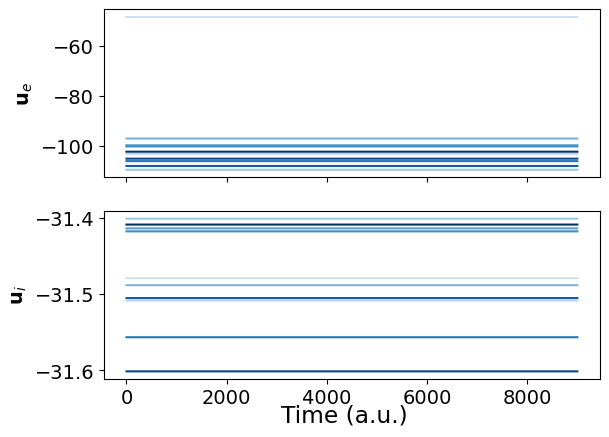

Evaluating 8 / 9 --> sigma = [7.500, 16.500]^T
[ 7.5        16.5         5.71582585 17.68172161  9.67325527 17.02221948
  7.17156249 16.97690807  6.23577792 15.01036027  7.61178187 16.59368463
  7.44040891 17.65923452  9.70278532 17.9544713   8.12354118 17.59357896
  6.77630706 14.99398965]


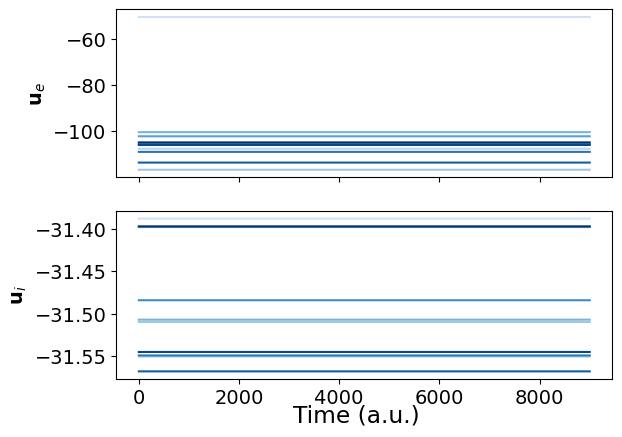

Evaluating 9 / 9 --> sigma = [16.500, 16.500]^T
[16.5        16.5        16.93362471 15.79366076 16.89304521 18.76944658
 16.35340195 15.91331429 16.8760223  16.57891896 18.30567038 16.98082923
 16.18159779 17.11301353 14.84888788 16.57016304 15.07917011 16.35966135
 15.61086403 17.29432692]


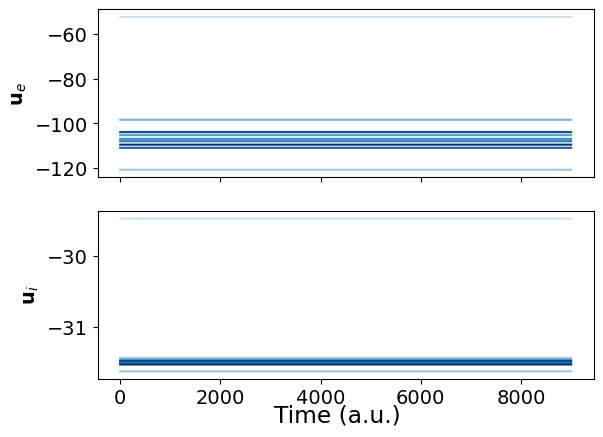

In [ ]:
for ns, (sige, sigi) in enumerate(sig_perm):
    print(f"Evaluating {ns + 1} / {len(sig_perm)} --> sigma = [{sige:.3f}, {sigi:.3f}]^T")
    sigma = np.random.multivariate_normal(sig_perm[ns], 1.2 * np.eye(2), nNodes)
    sigma[0, :] = sig_perm[ns]

    params['sigma'] = sigma.flatten()
    print(params['sigma'])

    fileName = f"sige_{params['sigma'][0]:.3f}_sigi_{params['sigma'][1]:.3f}_Imod_{params['i_mod']:.3f}mV_KGlob_{params['Kglob']:.2f}.pkl"

    u = np.zeros((nTrials, 2 * nNodes, T))
    u = euler_intergrate(u, xInit, modNodes = modNodes, **params)

    uMeanTrial = np.mean(u, axis=0)

    fig, axs = plt.subplots(2, 1, sharex=True)

    axs[0].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))
    axs[1].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

    for n in range(nNodes):
        axs[0].plot(time_[:-t_start], uMeanTrial[2 * n, t_start : ])
        axs[1].plot(time_[:-t_start], uMeanTrial[2 * n + 1, t_start : ])
    
    axs[0].set_ylabel(r"$\mathbf{u}_e$")
    axs[1].set_ylabel(r"$\mathbf{u}_i$")
    fig.supxlabel('Time (a.u.)')
    plt.show()

    




In [40]:
# Creating sigma array with covariance
sigma_arr = np.zeros((10, 2 * 10))

sigMean = np.array([2.5, 4.4])
for q in range(10):
    np.random.seed(q * 10 + 5)
    sigma_e = np.random.normal(2.5, 0.01, 10)
    sigma_i = np.random.normal(4.4, 0.01, 10)
    sigma_arr[q, 0::2] = sigma_e
    sigma_arr[q, 1::2] = sigma_i
    sigma_arr[q, 0] = 2.5
    sigma_arr[q, 1] = 4.4
    sigmaNet = np.random.multivariate_normal(sigMean, 0.01 ** 2 * np.eye(2), 10)
    # sigma_arr[q, :] = abs(sigmaNet.flatten())

# params['sigma'] = np.mean(sigma_arr, axis=0)

In [43]:
sigma_arr

array([[2.5       , 4.4       , 2.4966913 , 4.39795123, 2.52430771,
        4.39641171, 2.49747908, 4.40603472, 2.5010961 , 4.38335211,
        2.51582481, 4.39299821, 2.49090768, 4.41151391, 2.49408363,
        4.41857331, 2.50187603, 4.3848882 , 2.4967013 , 4.40644848],
       [2.5       , 4.4       , 2.50339285, 4.40355197, 2.49844091,
        4.40689518, 2.4949821 , 4.4041059 , 2.50235569, 4.39435022,
        2.48236395, 4.40599391, 2.48904138, 4.39837064, 2.48912234,
        4.41600215, 2.4969483 , 4.40681627, 2.49526252, 4.4001488 ],
       [2.5       , 4.4       , 2.5102689 , 4.39767688, 2.49160415,
        4.42152957, 2.49408818, 4.38665339, 2.49043112, 4.4007638 ,
        2.49777674, 4.38753911, 2.49380085, 4.41202272, 2.51837905,
        4.38950058, 2.47946769, 4.4105661 , 2.50868583, 4.39580322],
       [2.5       , 4.4       , 2.49586408, 4.3881848 , 2.49233974,
        4.39323849, 2.49075873, 4.39833773, 2.48578402, 4.40467435,
        2.50805256, 4.40333719, 2.51148862, 4

In [42]:
sigmaNet.flatten()

array([2.49697778, 4.39874861, 2.50963005, 4.39367643, 2.49157206,
       4.39305293, 2.50243141, 4.39969976, 2.50711798, 4.39736235,
       2.48576057, 4.38698114, 2.49844703, 4.39985439, 2.49318295,
       4.40132689, 2.49566924, 4.39174191, 2.49786335, 4.40406142])

In [31]:
np.corrcoef(pts.T)[0, 1]

-0.01544627671932279